# Previsao de Precos de Passagens Aereas com Big Data

Pipeline em PySpark sobre o dataset Expedia (~82M registros, 16 aeroportos).
Estrutura do notebook:

1. Ambiente Big Data e setup
2. Carregamento do dataset
3. Pre-processamento
4. Engenharia de atributos
5. Analise exploratoria
6. Modelagem


## 1. Ambiente Big Data e Setup


### 1.1 Imports


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from functools import reduce
from IPython.display import display
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator
from pyspark.ml.feature import OneHotEncoder, StandardScaler, StringIndexer, VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.ml.regression import DecisionTreeRegressor, LinearRegression

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


### 1.2 Sessao Spark e helpers

A funcao get_or_create_spark inicializa a sessao Spark conectada ao cluster do
projeto e habilita previews legiveis. A funcao run_sql encapsula o padrao
de consulta e exibicao usado nas analises exploratorias.


In [2]:
APP_NAME = "flight-price-sql-mllib"
SPARK_MASTER_URL = os.environ.get("SPARK_MASTER", "spark://spark-master:7077")


def get_or_create_spark(app_name: str = APP_NAME) -> SparkSession:
    spark_session = (
        SparkSession.builder
        .appName(app_name)
        .master(SPARK_MASTER_URL)
        .config("spark.sql.shuffle.partitions", "16")
        .config("spark.sql.session.timeZone", "UTC")
        .config("spark.sql.legacy.timeParserPolicy", "LEGACY")
        .config("spark.sql.repl.eagerEval.enabled", "true")
        .config("spark.sql.repl.eagerEval.maxNumRows", "20")
        .config("spark.sql.repl.eagerEval.truncate", "80")
        .getOrCreate()
    )
    spark_session.sparkContext.setLogLevel("WARN")
    return spark_session


def run_sql(query: str, preview_rows: int = 20):
    df = spark.sql(query)
    display(df.limit(preview_rows).toPandas())
    return df


### 1.3 Evidencias do ambiente distribuido

A Parte 1 do projeto e validada aqui de forma simples: a sessao Spark abaixo
mostra a conexao com o cluster, e a leitura do dataset prioriza o caminho
hdfs://namenode:9000/..., evidenciando o uso do HDFS no pipeline.


## 2. Carregamento do Dataset

### 2.1 Caminhos do dataset

O Parquet (~6.8 GB, snappy, particionado por startingAirport) e gerado por
make convert-local na raiz do projeto. LOAD_SAMPLE_RATIO controla a fracao
do dataset usada - 0.01 (~820 mil linhas) e o padrao atual para iteracao rapida; subir para
1.0 para benchmarks finais.


In [3]:
HDFS_PARQUET_PATH  = "hdfs://namenode:9000/data/itineraries.parquet"
LOCAL_PARQUET_PATH = "/data/itineraries.parquet"

LOAD_SAMPLE_RATIO = 0.01
DEV_SAMPLE_RATIO = 1.0


def resolve_parquet_paths(spark_session: SparkSession) -> list[str]:
    if spark_session.sparkContext.master.startswith("local"):
        return [HDFS_PARQUET_PATH, LOCAL_PARQUET_PATH]
    return [HDFS_PARQUET_PATH]


def load_flights(spark_session: SparkSession, candidate_paths: list[str]):
    last_error = None
    print(f"Tentando carregar Parquet pelos caminhos: {candidate_paths}")
    for path in candidate_paths:
        try:
            df = spark_session.read.parquet(path)
            print(f"Dataset registrado: {path}")
            return df, path
        except Exception as exc:
            print(f"Falha ao carregar {path}: {exc}")
            last_error = exc
    raise RuntimeError(
        "Nao foi possivel carregar o dataset Parquet. "
        "Rode `make convert-local` no projeto para gera-lo."
    ) from last_error


def apply_load_sample(df, ratio: float):
    if ratio >= 1.0:
        print("Usando dataset completo apos a leitura.")
        return df
    print(f"Aplicando amostra de carga com ratio={ratio} para acelerar as iteracoes.")
    return df.sample(withReplacement=False, fraction=ratio, seed=42)


### 2.2 Leitura


In [4]:
spark = get_or_create_spark()
candidate_paths = resolve_parquet_paths(spark)
raw_input_df, source_path = load_flights(spark, candidate_paths)
raw_df = apply_load_sample(raw_input_df, LOAD_SAMPLE_RATIO)
raw_df.createOrReplaceTempView("flights_raw")

print("Spark version:", spark.version)
print("Spark master:", spark.sparkContext.master)
print("Spark app name:", spark.sparkContext.appName)
print("Default FS:", spark.sparkContext._jsc.hadoopConfiguration().get("fs.defaultFS"))
print("Shuffle partitions:", spark.conf.get("spark.sql.shuffle.partitions"))
print("Default parallelism:", spark.sparkContext.defaultParallelism)
print("Source path:", source_path)
print("Load sample ratio:", LOAD_SAMPLE_RATIO)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/10 21:37:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Tentando carregar Parquet pelos caminhos: ['hdfs://namenode:9000/data/itineraries.parquet']


Dataset registrado: hdfs://namenode:9000/data/itineraries.parquet
Aplicando amostra de carga com ratio=0.01 para acelerar as iteracoes.
Spark version: 3.5.3
Spark master: spark://spark-master:7077
Spark app name: flight-price-sql-mllib
Default FS: file:///
Shuffle partitions: 16
Default parallelism: 6
Source path: hdfs://namenode:9000/data/itineraries.parquet
Load sample ratio: 0.01


26/05/10 21:37:37 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


### 2.3 Amostra dos dados brutos


In [5]:
run_sql("SELECT * FROM flights_raw LIMIT 5")


,legId,searchDate,flightDate,destinationAirport,fareBasisCode,travelDuration,elapsedDays,isBasicEconomy,isRefundable,isNonStop,...,segmentsArrivalTimeRaw,segmentsArrivalAirportCode,segmentsDepartureAirportCode,segmentsAirlineName,segmentsAirlineCode,segmentsEquipmentDescription,segmentsDurationInSeconds,segmentsDistance,segmentsCabinCode,startingAirport
0,12bd07f9808478cf4a6f24879a8a0cfa,2022-06-22,2022-08-12,BOS,G3AIZNN1,PT12H19M,1,False,False,False,...,2022-08-13T06:00:00.000-04:00||2022-08-13T13:4...,CLT||BOS,ONT||CLT,American Airlines||American Airlines,AA||AA,Boeing 737-800||Airbus A321,16740||8400,2076||728,coach||coach,LAX
1,dea0dbeae538b1415e6d626c01befde7,2022-06-22,2022-08-12,CLT,KA7OA0MQ,PT8H56M,0,False,False,False,...,2022-08-12T08:32:00.000-06:00||2022-08-12T17:4...,SLC||CLT,ONT||SLC,Delta||Delta,DL||DL,Airbus A321||Airbus A321,6180||14520,559||1724,coach||coach,LAX
2,2b2cad01d23972d950906a9c0fd321be,2022-06-22,2022-08-12,CLT,S3AJZNN1,PT10H2M,1,False,False,False,...,2022-08-12T18:38:00.000-07:00||2022-08-13T06:2...,LAS||CLT,LAX||LAS,American Airlines||American Airlines,AA||AA,Airbus A321||Airbus A321,4440||15240,241||1905,coach||coach,LAX
3,c9d75fe668da95428db39fffbb6311f7,2022-06-23,2022-07-31,DTW,QAUOA0MQ,PT13H26M,1,False,False,False,...,2022-07-31T22:10:00.000-05:00||2022-08-01T09:2...,AUS||DTW,LAX||AUS,Delta||Delta,DL||DL,Airbus A320||Airbus A319,11400||10560,1236||1155,coach||coach,LAX
4,d111ef1271d8bd2e912e7974118180bd,2022-06-23,2022-07-31,JFK,HVAHZNN1,PT5H43M,1,False,False,True,...,2022-08-01T08:28:00.000-04:00,JFK,LAX,American Airlines,AA,AIRBUS INDUSTRIE A321 SHARKLETS,20580,2458,coach,LAX


legId,searchDate,flightDate,destinationAirport,fareBasisCode,travelDuration,elapsedDays,isBasicEconomy,isRefundable,isNonStop,baseFare,totalFare,seatsRemaining,totalTravelDistance,segmentsDepartureTimeEpochSeconds,segmentsDepartureTimeRaw,segmentsArrivalTimeEpochSeconds,segmentsArrivalTimeRaw,segmentsArrivalAirportCode,segmentsDepartureAirportCode,segmentsAirlineName,segmentsAirlineCode,segmentsEquipmentDescription,segmentsDurationInSeconds,segmentsDistance,segmentsCabinCode,startingAirport
12bd07f9808478cf4a6f24879a8a0cfa,2022-06-22,2022-08-12,BOS,G3AIZNN1,PT12H19M,1,false,false,false,498.61,563.71,2,2804.0,1660368060||1660404000,2022-08-12T22:21:00.000-07:00||2022-08-13T11:20:00.000-04:00,1660384800||1660412400,2022-08-13T06:00:00.000-04:00||2022-08-13T13:40:00.000-04:00,CLT||BOS,ONT||CLT,American Airlines||American Airlines,AA||AA,Boeing 737-800||Airbus A321,16740||8400,2076||728,coach||coach,LAX
dea0dbeae538b1415e6d626c01befde7,2022-06-22,2022-08-12,CLT,KA7OA0MQ,PT8H56M,0,false,false,false,330.23,378.6,4,2283.0,1660308540||1660326180,2022-08-12T05:49:00.000-07:00||2022-08-12T11:43:00.000-06:00,1660314720||1660340700,2022-08-12T08:32:00.000-06:00||2022-08-12T17:45:00.000-04:00,SLC||CLT,ONT||SLC,Delta||Delta,DL||DL,Airbus A321||Airbus A321,6180||14520,559||1724,coach||coach,LAX
2b2cad01d23972d950906a9c0fd321be,2022-06-22,2022-08-12,CLT,S3AJZNN1,PT10H2M,1,false,false,false,470.7,535.2,7,2146.0,1660350240||1660371120,2022-08-12T17:24:00.000-07:00||2022-08-12T23:12:00.000-07:00,1660354680||1660386360,2022-08-12T18:38:00.000-07:00||2022-08-13T06:26:00.000-04:00,LAS||CLT,LAX||LAS,American Airlines||American Airlines,AA||AA,Airbus A321||Airbus A321,4440||15240,241||1905,coach||coach,LAX
c9d75fe668da95428db39fffbb6311f7,2022-06-23,2022-07-31,DTW,QAUOA0MQ,PT13H26M,1,false,false,false,407.44,467.2,9,2391.0,1659312000||1659349800,2022-07-31T17:00:00.000-07:00||2022-08-01T05:30:00.000-05:00,1659323400||1659360360,2022-07-31T22:10:00.000-05:00||2022-08-01T09:26:00.000-04:00,AUS||DTW,LAX||AUS,Delta||Delta,DL||DL,Airbus A320||Airbus A319,11400||10560,1236||1155,coach||coach,LAX
d111ef1271d8bd2e912e7974118180bd,2022-06-23,2022-07-31,JFK,HVAHZNN1,PT5H43M,1,false,false,true,841.86,919.6,7,2458.0,1659336300,2022-07-31T23:45:00.000-07:00,1659356880,2022-08-01T08:28:00.000-04:00,JFK,LAX,American Airlines,AA,AIRBUS INDUSTRIE A321 SHARKLETS,20580,2458,coach,LAX


## 3. Pre-processamento

Limpeza e conversao de tipo. Sem features derivadas ainda; elas entram na etapa
seguinte. Esta secao produz a view `flights_typed` com colunas tipadas (datas em
`DATE`, flags em `0/1`, numericos em `DOUBLE`/`INT`) e arrays parseados das
colunas `segments*`.


### 3.1 Conversao de tipos e parsing dos segmentos

- `searchDate` e `flightDate` -> `DATE`
- `isBasicEconomy`, `isRefundable` e `isNonStop` -> `INT (0/1)`
- `baseFare`, `totalFare` e `totalTravelDistance` -> `DOUBLE`
- `seatsRemaining` e `elapsedDays` -> `INT`
- `travelDuration` ISO-8601 -> minutos (`travel_duration_minutes`)
- Colunas `segments*` (`||`) -> arrays via `SPLIT` + `FILTER`

`fare_basis_prefix` extrai o primeiro caractere de `fareBasisCode` como proxy de
classe tarifaria para a EDA.


In [6]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW flights_typed AS
SELECT
    legId AS leg_id,
    TO_DATE(searchDate) AS search_date,
    TO_DATE(flightDate) AS flight_date,
    startingAirport AS starting_airport,
    destinationAirport AS destination_airport,
    fareBasisCode AS fare_basis_code,
    UPPER(SUBSTRING(COALESCE(fareBasisCode, 'UNK'), 1, 1)) AS fare_basis_prefix,
    travelDuration AS travel_duration_iso,
    CAST(elapsedDays AS INT) AS overnight_days,
    CASE WHEN LOWER(CAST(isBasicEconomy AS STRING)) = 'true' THEN 1 ELSE 0 END AS is_basic_economy,
    CASE WHEN LOWER(CAST(isRefundable  AS STRING)) = 'true' THEN 1 ELSE 0 END AS is_refundable,
    CASE WHEN LOWER(CAST(isNonStop     AS STRING)) = 'true' THEN 1 ELSE 0 END AS is_non_stop,
    CAST(baseFare  AS DOUBLE) AS base_fare,
    CAST(totalFare AS DOUBLE) AS total_fare,
    CAST(seatsRemaining AS INT) AS seats_remaining,
    CAST(totalTravelDistance AS DOUBLE) AS total_travel_distance,
    (
        CAST(CASE WHEN REGEXP_EXTRACT(travelDuration, '([0-9]+)D', 1) = '' THEN '0' ELSE REGEXP_EXTRACT(travelDuration, '([0-9]+)D', 1) END AS INT) * 1440
      + CAST(CASE WHEN REGEXP_EXTRACT(travelDuration, '([0-9]+)H', 1) = '' THEN '0' ELSE REGEXP_EXTRACT(travelDuration, '([0-9]+)H', 1) END AS INT) * 60
      + CAST(CASE WHEN REGEXP_EXTRACT(travelDuration, '([0-9]+)M', 1) = '' THEN '0' ELSE REGEXP_EXTRACT(travelDuration, '([0-9]+)M', 1) END AS INT)
    ) AS travel_duration_minutes,
    CAST(NULLIF(REGEXP_EXTRACT(COALESCE(segmentsDepartureTimeRaw, ''), 'T([0-9]{2}):', 1), '') AS INT) AS departure_hour,
    COALESCE(segmentsDepartureAirportCode, '') AS segments_departure_airport_code_raw,
    FILTER(SPLIT(REPLACE(COALESCE(segmentsDepartureAirportCode, ''), '||', '~'), '~'), x -> TRIM(x) <> '') AS departure_airport_segments,
    FILTER(SPLIT(REPLACE(COALESCE(segmentsDurationInSeconds,    ''), '||', '~'), '~'), x -> TRIM(x) <> '') AS duration_seconds_segments,
    FILTER(SPLIT(REPLACE(COALESCE(segmentsDistance,             ''), '||', '~'), '~'), x -> TRIM(x) <> '' AND LOWER(TRIM(x)) <> 'none') AS distance_segments,
    FILTER(SPLIT(REPLACE(COALESCE(segmentsAirlineCode,          ''), '||', '~'), '~'), x -> TRIM(x) <> '') AS airline_segments,
    FILTER(SPLIT(REPLACE(COALESCE(segmentsCabinCode,            ''), '||', '~'), '~'), x -> TRIM(x) <> '') AS cabin_segments
FROM flights_raw
WHERE totalFare IS NOT NULL
""")


""


### 3.2 Verificacao rapida do schema tipado


In [7]:
run_sql("SELECT * FROM flights_typed LIMIT 5")


,leg_id,search_date,flight_date,starting_airport,destination_airport,fare_basis_code,fare_basis_prefix,travel_duration_iso,overnight_days,is_basic_economy,...,seats_remaining,total_travel_distance,travel_duration_minutes,departure_hour,segments_departure_airport_code_raw,departure_airport_segments,duration_seconds_segments,distance_segments,airline_segments,cabin_segments
0,12bd07f9808478cf4a6f24879a8a0cfa,2022-06-22,2022-08-12,LAX,BOS,G3AIZNN1,G,PT12H19M,1,0,...,2,2804.0,739,22,ONT||CLT,"[ONT, CLT]","[16740, 8400]","[2076, 728]","[AA, AA]","[coach, coach]"
1,dea0dbeae538b1415e6d626c01befde7,2022-06-22,2022-08-12,LAX,CLT,KA7OA0MQ,K,PT8H56M,0,0,...,4,2283.0,536,5,ONT||SLC,"[ONT, SLC]","[6180, 14520]","[559, 1724]","[DL, DL]","[coach, coach]"
2,2b2cad01d23972d950906a9c0fd321be,2022-06-22,2022-08-12,LAX,CLT,S3AJZNN1,S,PT10H2M,1,0,...,7,2146.0,602,17,LAX||LAS,"[LAX, LAS]","[4440, 15240]","[241, 1905]","[AA, AA]","[coach, coach]"
3,c9d75fe668da95428db39fffbb6311f7,2022-06-23,2022-07-31,LAX,DTW,QAUOA0MQ,Q,PT13H26M,1,0,...,9,2391.0,806,17,LAX||AUS,"[LAX, AUS]","[11400, 10560]","[1236, 1155]","[DL, DL]","[coach, coach]"
4,d111ef1271d8bd2e912e7974118180bd,2022-06-23,2022-07-31,LAX,JFK,HVAHZNN1,H,PT5H43M,1,0,...,7,2458.0,343,23,LAX,[LAX],[20580],[2458],[AA],[coach]


leg_id,search_date,flight_date,starting_airport,destination_airport,fare_basis_code,fare_basis_prefix,travel_duration_iso,overnight_days,is_basic_economy,is_refundable,is_non_stop,base_fare,total_fare,seats_remaining,total_travel_distance,travel_duration_minutes,departure_hour,segments_departure_airport_code_raw,departure_airport_segments,duration_seconds_segments,distance_segments,airline_segments,cabin_segments
12bd07f9808478cf4a6f24879a8a0cfa,2022-06-22,2022-08-12,LAX,BOS,G3AIZNN1,G,PT12H19M,1,0,0,0,498.61,563.71,2,2804.0,739,22,ONT||CLT,"[ONT, CLT]","[16740, 8400]","[2076, 728]","[AA, AA]","[coach, coach]"
dea0dbeae538b1415e6d626c01befde7,2022-06-22,2022-08-12,LAX,CLT,KA7OA0MQ,K,PT8H56M,0,0,0,0,330.23,378.6,4,2283.0,536,5,ONT||SLC,"[ONT, SLC]","[6180, 14520]","[559, 1724]","[DL, DL]","[coach, coach]"
2b2cad01d23972d950906a9c0fd321be,2022-06-22,2022-08-12,LAX,CLT,S3AJZNN1,S,PT10H2M,1,0,0,0,470.7,535.2,7,2146.0,602,17,LAX||LAS,"[LAX, LAS]","[4440, 15240]","[241, 1905]","[AA, AA]","[coach, coach]"
c9d75fe668da95428db39fffbb6311f7,2022-06-23,2022-07-31,LAX,DTW,QAUOA0MQ,Q,PT13H26M,1,0,0,0,407.44,467.2,9,2391.0,806,17,LAX||AUS,"[LAX, AUS]","[11400, 10560]","[1236, 1155]","[DL, DL]","[coach, coach]"
d111ef1271d8bd2e912e7974118180bd,2022-06-23,2022-07-31,LAX,JFK,HVAHZNN1,H,PT5H43M,1,0,0,1,841.86,919.6,7,2458.0,343,23,LAX,[LAX],[20580],[2458],[AA],[coach]


## 4. Engenharia de Atributos

Sobre `flights_typed`, derivamos as features que entram tanto na EDA quanto no
modelo. A saida e a view `flights_clean`, com colunas de calendario, contagem de
escalas, estatisticas de segmento e derivados de distancia e duracao. Em seguida,
`flights_dev` aplica `DEV_SAMPLE_RATIO` para iteracao rapida (mantido em `1.0`
por padrao).

Atributos criados:

| Categoria | Colunas |
|---|---|
| Temporais | `days_until_flight`, `flight_day_of_week`, `flight_month`, `is_weekend` |
| Rota | `route` (origem-destino) |
| Escalas | `segment_count`, `stop_count`, `layover_minutes`, `travel_minus_segment_minutes` |
| Distancia | `distance_per_segment`, `effective_distance`, `has_missing_segment_distance` |
| Diversidade | `distinct_airline_count`, `distinct_cabin_count` |
| Duracao | `segment_duration_sum_minutes`, `segment_duration_avg_minutes` |


In [8]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW flights_clean AS
WITH prepared AS (
    SELECT
        *,
        DATEDIFF(flight_date, search_date) AS days_until_flight,
        DAYOFWEEK(flight_date) AS flight_day_of_week,
        MONTH(flight_date) AS flight_month,
        CONCAT(starting_airport, '-', destination_airport) AS route,
        CASE
            WHEN segments_departure_airport_code_raw IS NULL OR TRIM(segments_departure_airport_code_raw) = '' THEN 0
            ELSE CAST(((LENGTH(segments_departure_airport_code_raw) - LENGTH(REPLACE(segments_departure_airport_code_raw, '||', ''))) / 2) + 1 AS INT)
        END AS segment_count,
        AGGREGATE(duration_seconds_segments, CAST(0.0 AS DOUBLE), (acc, x) -> acc + COALESCE(CAST(x AS DOUBLE), 0.0D)) / 60.0 AS segment_duration_sum_minutes,
        AGGREGATE(distance_segments,         CAST(0.0 AS DOUBLE), (acc, x) -> acc + COALESCE(CAST(x AS DOUBLE), 0.0D)) AS known_segment_distance,
        SIZE(distance_segments) AS known_segment_distance_count,
        SIZE(ARRAY_DISTINCT(airline_segments)) AS distinct_airline_count,
        SIZE(ARRAY_DISTINCT(cabin_segments))   AS distinct_cabin_count
    FROM flights_typed
)
SELECT
    leg_id,
    search_date,
    flight_date,
    starting_airport,
    destination_airport,
    fare_basis_code,
    fare_basis_prefix,
    travel_duration_iso,
    overnight_days,
    days_until_flight,
    is_basic_economy,
    is_refundable,
    is_non_stop,
    base_fare,
    total_fare,
    seats_remaining,
    total_travel_distance,
    travel_duration_minutes,
    departure_hour,
    segment_count,
    GREATEST(segment_count - 1, 0) AS stop_count,
    segment_duration_sum_minutes,
    CASE WHEN segment_count > 0 THEN segment_duration_sum_minutes / segment_count END AS segment_duration_avg_minutes,
    known_segment_distance,
    known_segment_distance_count,
    CASE
        WHEN total_travel_distance IS NULL OR isnan(total_travel_distance) THEN known_segment_distance
        ELSE total_travel_distance
    END AS effective_distance,
    CASE WHEN segment_count > 0 THEN known_segment_distance / segment_count END AS distance_per_segment,
    CASE WHEN segment_count <= 1 THEN 0.0D
         ELSE GREATEST(travel_duration_minutes - segment_duration_sum_minutes, 0.0D)
    END AS layover_minutes,
    GREATEST(travel_duration_minutes - segment_duration_sum_minutes, 0.0D) AS travel_minus_segment_minutes,
    CASE WHEN segment_count > known_segment_distance_count THEN 1 ELSE 0 END AS has_missing_segment_distance,
    distinct_airline_count,
    distinct_cabin_count,
    flight_day_of_week,
    flight_month,
    CASE WHEN DAYOFWEEK(flight_date) IN (1, 7) THEN 1 ELSE 0 END AS is_weekend,
    route
FROM prepared
""")

if DEV_SAMPLE_RATIO < 1.0:
    spark.sql(f"""
    CREATE OR REPLACE TEMP VIEW flights_dev AS
    SELECT * FROM flights_clean WHERE rand(42) <= {DEV_SAMPLE_RATIO}
    """)
else:
    spark.sql("CREATE OR REPLACE TEMP VIEW flights_dev AS SELECT * FROM flights_clean")

# Cache: flights_dev e reusada em todas as queries de EDA e modelagem.
spark.table("flights_dev").cache().count()


820303

### 4.2 Validacao de qualidade dos atributos

Conta linhas com sinais de inconsistencia. O esperado e zero em todos os campos;
qualquer divergencia aqui indica necessidade de revisar o pre-processamento ou a
engenharia de atributos.


In [9]:
run_sql("""
SELECT
    COUNT(*)                                                                                AS total_rows,
    SUM(CASE WHEN days_until_flight       <  0    THEN 1 ELSE 0 END)                        AS invalid_days_until_flight,
    SUM(CASE WHEN segment_count           <= 0    THEN 1 ELSE 0 END)                        AS invalid_segment_count,
    SUM(CASE WHEN segment_count           >  4    THEN 1 ELSE 0 END)                        AS invalid_segment_upper_bound,
    SUM(CASE WHEN travel_duration_minutes <= 0    THEN 1 ELSE 0 END)                        AS invalid_travel_duration,
    SUM(CASE WHEN departure_hour IS NOT NULL AND (departure_hour < 0 OR departure_hour > 23)
             THEN 1 ELSE 0 END)                                                              AS invalid_departure_hour,
    SUM(CASE WHEN layover_minutes < 0     THEN 1 ELSE 0 END)                                AS negative_layover_signal,
    SUM(CASE WHEN is_non_stop = 1 AND stop_count <> 0      THEN 1 ELSE 0 END)               AS invalid_non_stop_stop_count,
    SUM(CASE WHEN is_non_stop = 1 AND layover_minutes > 15 THEN 1 ELSE 0 END)               AS non_stop_with_layover,
    MIN(total_fare) AS min_total_fare,
    MAX(total_fare) AS max_total_fare,
    ROUND(AVG(total_fare),               2) AS avg_total_fare,
    ROUND(AVG(travel_duration_minutes),  2) AS avg_duration_minutes,
    ROUND(AVG(days_until_flight),        2) AS avg_days_until_flight,
    ROUND(AVG(layover_minutes),          2) AS avg_layover_minutes
FROM flights_dev
""")


,total_rows,invalid_days_until_flight,invalid_segment_count,invalid_segment_upper_bound,invalid_travel_duration,invalid_departure_hour,negative_layover_signal,invalid_non_stop_stop_count,non_stop_with_layover,min_total_fare,max_total_fare,avg_total_fare,avg_duration_minutes,avg_days_until_flight,avg_layover_minutes
0,820303,0,0,1,0,0,0,0,0,19.59,4923.6,340.9,428.65,26.89,143.93


total_rows,invalid_days_until_flight,invalid_segment_count,invalid_segment_upper_bound,invalid_travel_duration,invalid_departure_hour,negative_layover_signal,invalid_non_stop_stop_count,non_stop_with_layover,min_total_fare,max_total_fare,avg_total_fare,avg_duration_minutes,avg_days_until_flight,avg_layover_minutes
820303,0,0,1,0,0,0,0,0,19.59,4923.6,340.9,428.65,26.89,143.93


## 5. Analise Explorataria

Padrao adotado: a agregacao e feita no Spark, e apenas o resultado pequeno e
trazido para o driver via `.toPandas()` para plot.


### 5.1 Distribuicao da variavel alvo (`total_fare`)

Resumo rapido da dispersao da tarifa total. O histograma e cortado no percentil
99 para manter legibilidade, enquanto os percentis e o maximo continuam sendo
mostrados na tabela-resumo.


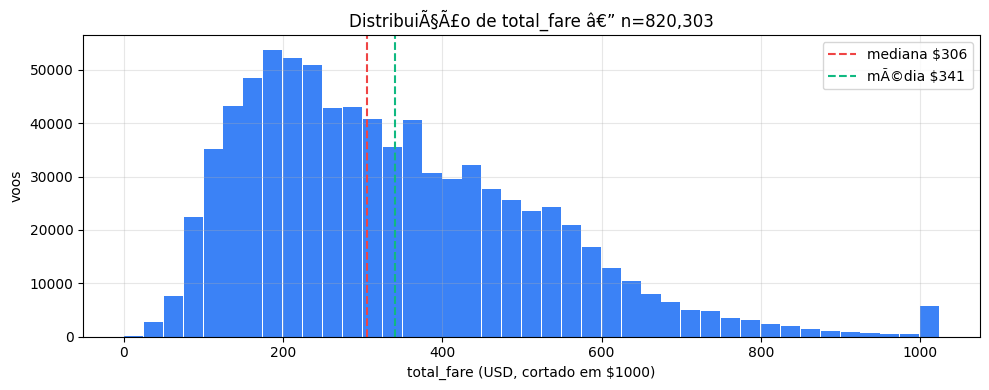

,min,p25,p50,mean,p95,p99,max
0,19.59,197.2,305.61,340.9,665.7,898.6,4923.6


In [10]:
_clip = 1000
_pdf = spark.sql(f"""
SELECT FLOOR(LEAST(total_fare, {_clip}) / 25) * 25 AS bin_start, COUNT(*) AS n
FROM flights_dev
WHERE total_fare > 0
GROUP BY bin_start
ORDER BY bin_start
""").toPandas()

_stats = spark.sql("""
SELECT
    ROUND(MIN(total_fare),                 2) AS min,
    ROUND(percentile_approx(total_fare, 0.25), 2) AS p25,
    ROUND(percentile_approx(total_fare, 0.50), 2) AS p50,
    ROUND(AVG(total_fare),                 2) AS mean,
    ROUND(percentile_approx(total_fare, 0.95), 2) AS p95,
    ROUND(percentile_approx(total_fare, 0.99), 2) AS p99,
    ROUND(MAX(total_fare),                 2) AS max
FROM flights_dev
""").toPandas()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(_pdf["bin_start"], _pdf["n"], width=24, align="edge", color="#3b82f6")
ax.axvline(_stats["p50"][0], color="#ef4444", linestyle="--", label=f"mediana ${_stats['p50'][0]:.0f}")
ax.axvline(_stats["mean"][0], color="#10b981", linestyle="--", label=f"media ${_stats['mean'][0]:.0f}")ax.set_xlabel("total_fare (USD, cortado em $1000)")
ax.set_ylabel("voos")
ax.set_title(f"Distribuicao de total_fare - n={_pdf['n'].sum():,}")ax.legend()
plt.tight_layout(); plt.show()

display(_stats)


### 5.2 Correlacao numerica com `total_fare`

Calcula a correlacao de Pearson entre cada feature numerica e `total_fare`.
`base_fare` aparece como referencia de consistencia, ja que `total_fare` e quase
sempre `base_fare` mais taxas.


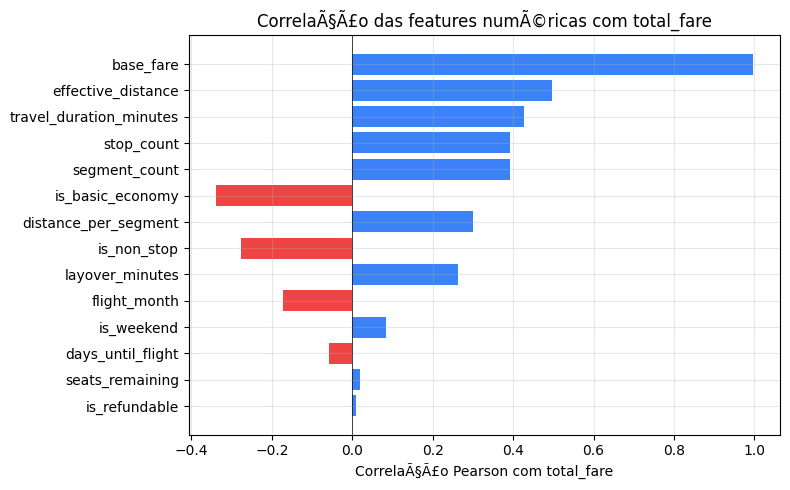

In [11]:
_num_cols = [
    "base_fare",
    "days_until_flight",
    "travel_duration_minutes",
    "segment_count",
    "stop_count",
    "layover_minutes",
    "effective_distance",
    "distance_per_segment",
    "seats_remaining",
    "is_basic_economy",
    "is_refundable",
    "is_non_stop",
    "flight_month",
    "is_weekend",
]
_corr_select = ", ".join(f"corr({c}, total_fare) AS {c}" for c in _num_cols)
_corr_pdf = spark.sql(f"SELECT {_corr_select} FROM flights_dev").toPandas().T
_corr_pdf.columns = ["corr"]
_corr_pdf = _corr_pdf.sort_values("corr", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
_colors = ["#ef4444" if v < 0 else "#3b82f6" for v in _corr_pdf["corr"]]
ax.barh(_corr_pdf.index, _corr_pdf["corr"], color=_colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Correlacao Pearson com total_fare")ax.set_title("Correlacao das features numericas com total_fare")plt.tight_layout(); plt.show()


### 5.3 Antecedencia da compra

`days_until_flight` varia de 1 a 60 dias. Os bins nao uniformes ajudam a separar
compra de ultima hora de compra antecipada.


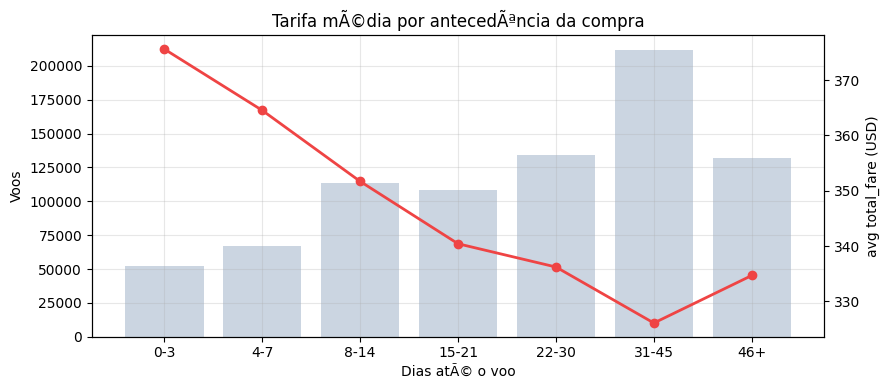

,bin,n,avg_fare
0,0-3,52544,375.59
1,4-7,67065,364.52
2,8-14,113853,351.69
3,15-21,108511,340.42
4,22-30,134157,336.22
5,31-45,211887,326.10
6,46+,132286,334.69


In [12]:
_pdf = spark.sql("""
SELECT
    CASE
        WHEN days_until_flight BETWEEN 0  AND 3  THEN '0-3'
        WHEN days_until_flight BETWEEN 4  AND 7  THEN '4-7'
        WHEN days_until_flight BETWEEN 8  AND 14 THEN '8-14'
        WHEN days_until_flight BETWEEN 15 AND 21 THEN '15-21'
        WHEN days_until_flight BETWEEN 22 AND 30 THEN '22-30'
        WHEN days_until_flight BETWEEN 31 AND 45 THEN '31-45'
        ELSE '46+'
    END                                 AS bin,
    COUNT(*)                            AS n,
    ROUND(AVG(total_fare), 2)          AS avg_fare
FROM flights_dev
WHERE days_until_flight IS NOT NULL AND days_until_flight >= 0
GROUP BY bin
""").toPandas()
_order = ["0-3", "4-7", "8-14", "15-21", "22-30", "31-45", "46+"]
_pdf = _pdf.set_index("bin").loc[_order].reset_index()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.bar(_pdf["bin"], _pdf["n"], color="#cbd5e1", label="volume")
ax2.plot(_pdf["bin"], _pdf["avg_fare"], color="#ef4444", marker="o", linewidth=2, label="avg_fare")
ax1.set_xlabel("Dias ate o voo")ax1.set_ylabel("Voos")
ax2.set_ylabel("avg total_fare (USD)")
ax1.set_title("Tarifa media por antecedencia da compra")ax2.grid(False)
plt.tight_layout(); plt.show()

display(_pdf)


### 5.4 Voos diretos vs. com escalas

Compara tarifa media por numero de paradas e sobrepoe o volume de voos por faixa.
A expectativa e custo maior em itinerarios mais complexos.


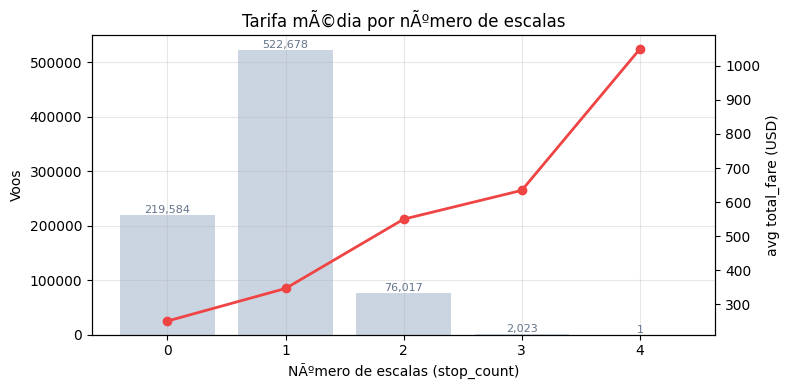

In [13]:
_pdf = spark.sql("""
SELECT stop_count, COUNT(*) AS n, ROUND(AVG(total_fare), 2) AS avg_fare
FROM flights_dev
WHERE stop_count IS NOT NULL
GROUP BY stop_count
ORDER BY stop_count
""").toPandas()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.bar(_pdf["stop_count"].astype(str), _pdf["n"], color="#cbd5e1", label="volume")
ax2.plot(_pdf["stop_count"].astype(str), _pdf["avg_fare"], color="#ef4444", marker="o", linewidth=2, label="avg_fare")
for i, (n, fare) in enumerate(zip(_pdf["n"], _pdf["avg_fare"])):
    ax1.text(i, n, f"{n:,}", ha="center", va="bottom", fontsize=8, color="#64748b")
ax1.set_xlabel("Numero de escalas (stop_count)")ax1.set_ylabel("Voos")
ax2.set_ylabel("avg total_fare (USD)")
ax1.set_title("Tarifa media por numero de escalas")ax2.grid(False)
plt.tight_layout(); plt.show()


### 5.5 Sazonalidade mensal

A base cobre de abril a novembro de 2022. O objetivo aqui e observar variacao de
preco medio e volume ao longo dos meses do voo.


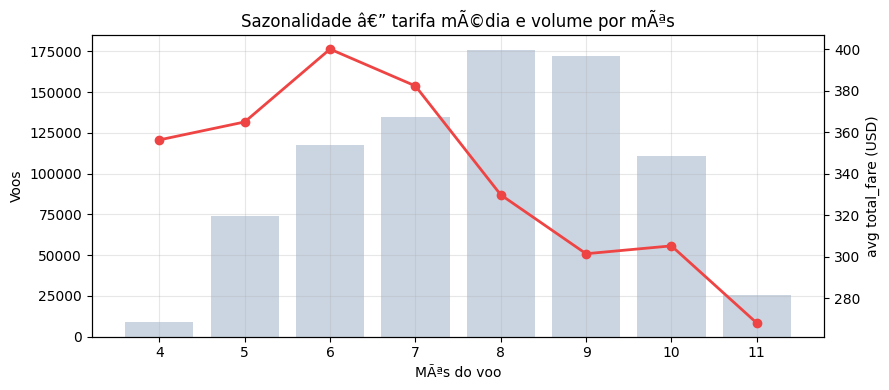

In [14]:
_pdf = spark.sql("""
SELECT flight_month AS month, COUNT(*) AS n, ROUND(AVG(total_fare), 2) AS avg_fare
FROM flights_dev
WHERE flight_month IS NOT NULL
GROUP BY flight_month
ORDER BY flight_month
""").toPandas()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.bar(_pdf["month"].astype(str), _pdf["n"], color="#cbd5e1", label="volume")
ax2.plot(_pdf["month"].astype(str), _pdf["avg_fare"], color="#ef4444", marker="o", linewidth=2, label="avg_fare")
ax1.set_xlabel("Mes do voo")ax1.set_ylabel("Voos")
ax2.set_ylabel("avg total_fare (USD)")
ax1.set_title("Sazonalidade - tarifa media e volume por mes")ax2.grid(False)
plt.tight_layout(); plt.show()


### 5.6 Top 20 rotas mais caras (media de `total_fare`)

Considera apenas rotas com volume suficiente para evitar que amostras muito
pequenas dominem o ranking.


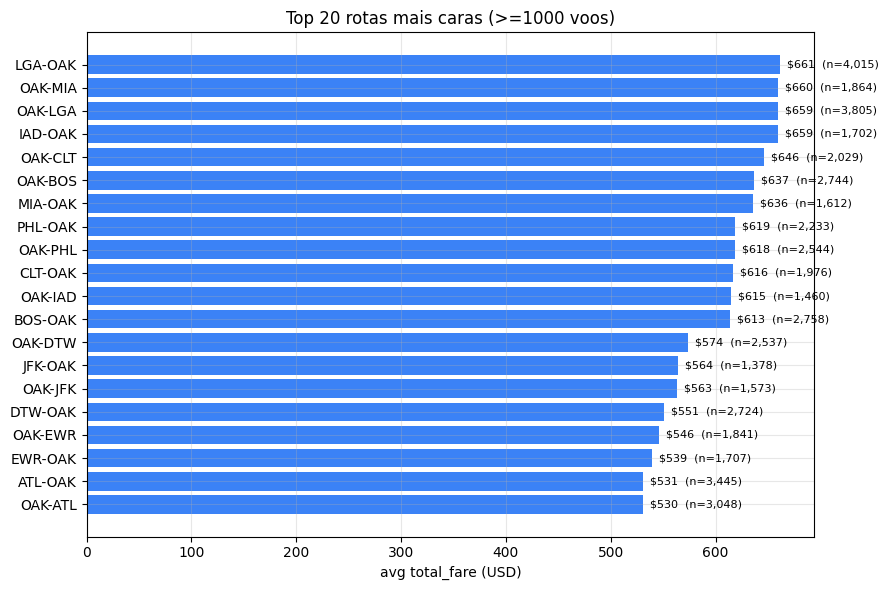

In [15]:
_pdf = spark.sql("""
SELECT route, COUNT(*) AS n, ROUND(AVG(total_fare), 2) AS avg_fare
FROM flights_dev
GROUP BY route
HAVING COUNT(*) >= 1000
ORDER BY avg_fare DESC
LIMIT 20
""").toPandas().iloc[::-1]  # invert for horizontal bar chart top->bottom

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(_pdf["route"], _pdf["avg_fare"], color="#3b82f6")
for i, (fare, n) in enumerate(zip(_pdf["avg_fare"], _pdf["n"])):
    ax.text(fare, i, f"  ${fare:.0f}  (n={n:,})", va="center", fontsize=8)
ax.set_xlabel("avg total_fare (USD)")
ax.set_title("Top 20 rotas mais caras (>=1000 voos)")
plt.tight_layout(); plt.show()


### 5.7 Classes tarifarias (prefixo de `fareBasisCode`)

Top 15 prefixos por volume, ordenados por tarifa media. Ajuda a observar a
hierarquia comercial entre classes tarifarias.


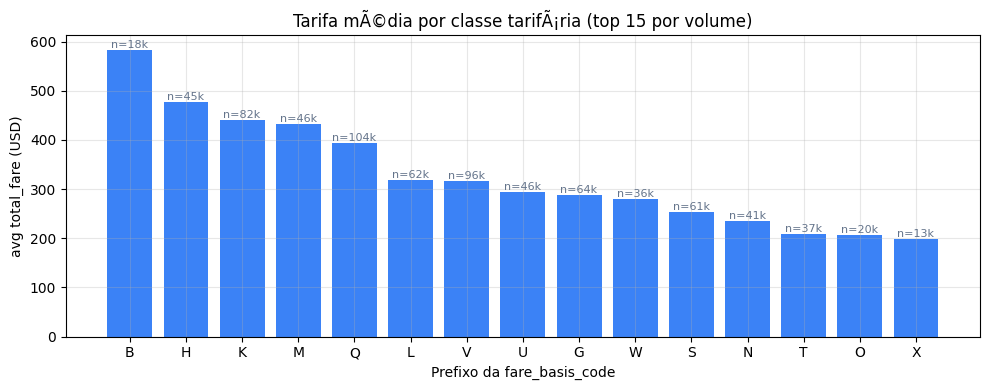

In [16]:
_top = spark.sql("""
SELECT fare_basis_prefix
FROM flights_dev
GROUP BY fare_basis_prefix
ORDER BY COUNT(*) DESC
LIMIT 15
""").toPandas()["fare_basis_prefix"].tolist()

_pdf = spark.sql(f"""
SELECT fare_basis_prefix, COUNT(*) AS n, ROUND(AVG(total_fare), 2) AS avg_fare
FROM flights_dev
WHERE fare_basis_prefix IN ({", ".join(repr(p) for p in _top)})
GROUP BY fare_basis_prefix
ORDER BY avg_fare DESC
""").toPandas()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(_pdf["fare_basis_prefix"], _pdf["avg_fare"], color="#3b82f6")
for i, (fare, n) in enumerate(zip(_pdf["avg_fare"], _pdf["n"])):
    ax.text(i, fare, f"n={n//1000}k", ha="center", va="bottom", fontsize=8, color="#64748b")
ax.set_xlabel("Prefixo da fare_basis_code")
ax.set_ylabel("avg total_fare (USD)")
ax.set_title("Tarifa media por classe tarifaria (top 15 por volume)")plt.tight_layout(); plt.show()


### 5.8 Sanity check de inconsistencias

Ultima verificacao antes da modelagem: linhas que violam os invariantes definidos
na etapa 4. O esperado e zero resultado relevante.


In [17]:
run_sql("""
SELECT
    route, travel_duration_iso, travel_duration_minutes,
    segment_count, stop_count, departure_hour, layover_minutes,
    days_until_flight, total_fare
FROM flights_dev
WHERE travel_duration_minutes <= 0
   OR segment_count <= 0
   OR days_until_flight < 0
   OR (departure_hour IS NOT NULL AND (departure_hour < 0 OR departure_hour > 23))
ORDER BY total_fare DESC
LIMIT 20
""")


,route,travel_duration_iso,travel_duration_minutes,segment_count,stop_count,departure_hour,layover_minutes,days_until_flight,total_fare


route,travel_duration_iso,travel_duration_minutes,segment_count,stop_count,departure_hour,layover_minutes,days_until_flight,total_fare


## 6. Modelagem


### 6.1 Filtros de qualidade para ML

Aplicamos restricoes conservadoras sobre `flights_dev` antes do treino. Mantemos
apenas voos com `segment_count` entre 1 e 4, duracoes e antecedencias em faixas
plausiveis e consistencia entre `is_non_stop` e `stop_count`.


In [18]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW flights_ml_base AS
SELECT
    leg_id,
    total_fare,
    base_fare,
    days_until_flight,
    overnight_days,
    seats_remaining,
    COALESCE(effective_distance, 0.0D) AS total_travel_distance,
    travel_duration_minutes,
    segment_count,
    stop_count,
    flight_day_of_week,
    flight_month,
    is_basic_economy,
    is_refundable,
    is_non_stop,
    route,
    flight_date,
    starting_airport,
    destination_airport,
    fare_basis_prefix,
    departure_hour,
    segment_duration_sum_minutes,
    segment_duration_avg_minutes,
    effective_distance,
    distance_per_segment,
    layover_minutes,
    has_missing_segment_distance,
    distinct_airline_count,
    distinct_cabin_count,
    is_weekend,
    travel_minus_segment_minutes
FROM flights_dev
WHERE total_fare              IS NOT NULL
  AND base_fare               IS NOT NULL
  AND days_until_flight       IS NOT NULL
  AND overnight_days          IS NOT NULL
  AND seats_remaining         IS NOT NULL
  AND travel_duration_minutes IS NOT NULL
  AND departure_hour          IS NOT NULL
  AND segment_count BETWEEN 1 AND 4
  AND departure_hour BETWEEN 0 AND 23
  AND travel_duration_minutes BETWEEN 30 AND 4320
  AND segment_duration_sum_minutes > 0
  AND days_until_flight BETWEEN 0 AND 365
  AND layover_minutes   BETWEEN 0 AND 1440
  AND (is_non_stop = 0 OR stop_count = 0)
  AND (is_non_stop = 0 OR layover_minutes <= 15)
""")

run_sql("""
SELECT
    COUNT(*)                                AS total_rows,
    MIN(flight_date)                        AS min_flight_date,
    MAX(flight_date)                        AS max_flight_date,
    ROUND(AVG(total_fare),         2)      AS avg_total_fare,
    ROUND(AVG(days_until_flight),  2)      AS avg_days_until_flight,
    ROUND(AVG(segment_count),      2)      AS avg_segment_count,
    ROUND(AVG(layover_minutes),    2)      AS avg_layover_minutes
FROM flights_ml_base
""")


,total_rows,min_flight_date,max_flight_date,avg_total_fare,avg_days_until_flight,avg_segment_count,avg_layover_minutes
0,820293,2022-04-17,2022-11-19,340.89,26.89,1.83,143.92


total_rows,min_flight_date,max_flight_date,avg_total_fare,avg_days_until_flight,avg_segment_count,avg_layover_minutes
820293,2022-04-17,2022-11-19,340.89,26.89,1.83,143.92


### 6.2 Split temporal treino/teste

O corte e feito no percentil 80 de `flight_date`: treina em datas anteriores e
avalia em datas posteriores. Isso reduz vazamento temporal em relacao a um split
aleatorio.


In [ ]:
cutoff_unix = spark.sql(
    "SELECT percentile_approx(unix_timestamp(flight_date), 0.8) AS cutoff_unix FROM flights_ml_base"
).first()["cutoff_unix"]

spark.sql(f"""
CREATE OR REPLACE TEMP VIEW flights_train AS
SELECT * FROM flights_ml_base WHERE unix_timestamp(flight_date) <= {cutoff_unix}
""")
spark.sql(f"""
CREATE OR REPLACE TEMP VIEW flights_test AS
SELECT * FROM flights_ml_base WHERE unix_timestamp(flight_date) >  {cutoff_unix}
""")

# More resolution at the premium tail: broad buckets for the body, tighter cuts at the top.
FARE_BAND_PERCENTILES = [0.20, 0.40, 0.60, 0.75, 0.85, 0.92, 0.97, 0.99, 0.995]
percentile_expr = ", ".join(f"{p:.3f}D" for p in FARE_BAND_PERCENTILES)
fare_band_cutoffs = spark.sql(
    f"SELECT percentile_approx(total_fare, array({percentile_expr}), 10000) AS cutoffs FROM flights_train"
).first()["cutoffs"]
fare_band_cutoffs = [float(value) for value in fare_band_cutoffs]
print("Fare band percentiles:", FARE_BAND_PERCENTILES)
print("Fare band cutoffs (train-only):", fare_band_cutoffs)

case_lines = []
for idx, cutoff in enumerate(fare_band_cutoffs):
    case_lines.append(f"        WHEN total_fare < {cutoff} THEN {float(idx):.1f}D")
fare_band_case_sql = "CASE\n" + "\n".join(case_lines) + f"\n        ELSE {float(len(fare_band_cutoffs)):.1f}D\n    END"

spark.sql(f"""
CREATE OR REPLACE TEMP VIEW flights_train_nn AS
SELECT
    *,
    {fare_band_case_sql} AS fare_band_label
FROM flights_train
""")
spark.sql(f"""
CREATE OR REPLACE TEMP VIEW flights_test_nn AS
SELECT
    *,
    {fare_band_case_sql} AS fare_band_label
FROM flights_test
""")

spark.sql("""
CREATE OR REPLACE TEMP VIEW train_global_priors AS
SELECT AVG(total_fare) AS global_avg_total_fare
FROM flights_train
""")
spark.sql("""
CREATE OR REPLACE TEMP VIEW train_route_priors AS
SELECT route, AVG(total_fare) AS route_avg_total_fare, COUNT(*) AS route_rows
FROM flights_train
GROUP BY route
""")
spark.sql("""
CREATE OR REPLACE TEMP VIEW train_route_stop_priors AS
SELECT route, stop_count, AVG(total_fare) AS route_stop_avg_total_fare, COUNT(*) AS route_stop_rows
FROM flights_train
GROUP BY route, stop_count
""")
spark.sql("""
CREATE OR REPLACE TEMP VIEW train_origin_priors AS
SELECT starting_airport, AVG(total_fare) AS origin_avg_total_fare, COUNT(*) AS origin_rows
FROM flights_train
GROUP BY starting_airport
""")
spark.sql("""
CREATE OR REPLACE TEMP VIEW train_destination_priors AS
SELECT destination_airport, AVG(total_fare) AS destination_avg_total_fare, COUNT(*) AS destination_rows
FROM flights_train
GROUP BY destination_airport
""")
spark.sql("""
CREATE OR REPLACE TEMP VIEW train_fare_basis_priors AS
SELECT fare_basis_prefix, AVG(total_fare) AS fare_basis_avg_total_fare, COUNT(*) AS fare_basis_rows
FROM flights_train
GROUP BY fare_basis_prefix
""")

spark.sql("""
CREATE OR REPLACE TEMP VIEW flights_train_enriched AS
SELECT
    base.*,
    global_priors.global_avg_total_fare,
    COALESCE(route_priors.route_avg_total_fare, global_priors.global_avg_total_fare) AS route_avg_total_fare,
    COALESCE(route_priors.route_rows, 0) AS route_rows,
    COALESCE(route_stop_priors.route_stop_avg_total_fare, route_priors.route_avg_total_fare, global_priors.global_avg_total_fare) AS route_stop_avg_total_fare,
    COALESCE(route_stop_priors.route_stop_rows, 0) AS route_stop_rows,
    COALESCE(origin_priors.origin_avg_total_fare, global_priors.global_avg_total_fare) AS origin_avg_total_fare,
    COALESCE(origin_priors.origin_rows, 0) AS origin_rows,
    COALESCE(destination_priors.destination_avg_total_fare, global_priors.global_avg_total_fare) AS destination_avg_total_fare,
    COALESCE(destination_priors.destination_rows, 0) AS destination_rows,
    COALESCE(fare_basis_priors.fare_basis_avg_total_fare, global_priors.global_avg_total_fare) AS fare_basis_avg_total_fare,
    COALESCE(fare_basis_priors.fare_basis_rows, 0) AS fare_basis_rows
FROM flights_train base
CROSS JOIN train_global_priors global_priors
LEFT JOIN train_route_priors route_priors
  ON base.route = route_priors.route
LEFT JOIN train_route_stop_priors route_stop_priors
  ON base.route = route_stop_priors.route AND base.stop_count = route_stop_priors.stop_count
LEFT JOIN train_origin_priors origin_priors
  ON base.starting_airport = origin_priors.starting_airport
LEFT JOIN train_destination_priors destination_priors
  ON base.destination_airport = destination_priors.destination_airport
LEFT JOIN train_fare_basis_priors fare_basis_priors
  ON base.fare_basis_prefix = fare_basis_priors.fare_basis_prefix
""")
spark.sql("""
CREATE OR REPLACE TEMP VIEW flights_test_enriched AS
SELECT
    base.*,
    global_priors.global_avg_total_fare,
    COALESCE(route_priors.route_avg_total_fare, global_priors.global_avg_total_fare) AS route_avg_total_fare,
    COALESCE(route_priors.route_rows, 0) AS route_rows,
    COALESCE(route_stop_priors.route_stop_avg_total_fare, route_priors.route_avg_total_fare, global_priors.global_avg_total_fare) AS route_stop_avg_total_fare,
    COALESCE(route_stop_priors.route_stop_rows, 0) AS route_stop_rows,
    COALESCE(origin_priors.origin_avg_total_fare, global_priors.global_avg_total_fare) AS origin_avg_total_fare,
    COALESCE(origin_priors.origin_rows, 0) AS origin_rows,
    COALESCE(destination_priors.destination_avg_total_fare, global_priors.global_avg_total_fare) AS destination_avg_total_fare,
    COALESCE(destination_priors.destination_rows, 0) AS destination_rows,
    COALESCE(fare_basis_priors.fare_basis_avg_total_fare, global_priors.global_avg_total_fare) AS fare_basis_avg_total_fare,
    COALESCE(fare_basis_priors.fare_basis_rows, 0) AS fare_basis_rows
FROM flights_test base
CROSS JOIN train_global_priors global_priors
LEFT JOIN train_route_priors route_priors
  ON base.route = route_priors.route
LEFT JOIN train_route_stop_priors route_stop_priors
  ON base.route = route_stop_priors.route AND base.stop_count = route_stop_priors.stop_count
LEFT JOIN train_origin_priors origin_priors
  ON base.starting_airport = origin_priors.starting_airport
LEFT JOIN train_destination_priors destination_priors
  ON base.destination_airport = destination_priors.destination_airport
LEFT JOIN train_fare_basis_priors fare_basis_priors
  ON base.fare_basis_prefix = fare_basis_priors.fare_basis_prefix
""")
spark.sql("""
CREATE OR REPLACE TEMP VIEW flights_train_nn_enriched AS
SELECT nn.*, enriched.global_avg_total_fare, enriched.route_avg_total_fare, enriched.route_rows,
       enriched.route_stop_avg_total_fare, enriched.route_stop_rows,
       enriched.origin_avg_total_fare, enriched.origin_rows,
       enriched.destination_avg_total_fare, enriched.destination_rows,
       enriched.fare_basis_avg_total_fare, enriched.fare_basis_rows
FROM flights_train_nn nn
JOIN flights_train_enriched enriched
  ON nn.route = enriched.route
 AND nn.flight_date = enriched.flight_date
 AND nn.departure_hour = enriched.departure_hour
 AND nn.total_fare = enriched.total_fare
 AND nn.leg_id = enriched.leg_id
""")
spark.sql("""
CREATE OR REPLACE TEMP VIEW flights_test_nn_enriched AS
SELECT nn.*, enriched.global_avg_total_fare, enriched.route_avg_total_fare, enriched.route_rows,
       enriched.route_stop_avg_total_fare, enriched.route_stop_rows,
       enriched.origin_avg_total_fare, enriched.origin_rows,
       enriched.destination_avg_total_fare, enriched.destination_rows,
       enriched.fare_basis_avg_total_fare, enriched.fare_basis_rows
FROM flights_test_nn nn
JOIN flights_test_enriched enriched
  ON nn.route = enriched.route
 AND nn.flight_date = enriched.flight_date
 AND nn.departure_hour = enriched.departure_hour
 AND nn.total_fare = enriched.total_fare
 AND nn.leg_id = enriched.leg_id
""")

run_sql("""
SELECT 'train' AS split_name, COUNT(*) AS total_rows,
       MIN(flight_date) AS min_flight_date, MAX(flight_date) AS max_flight_date FROM flights_train
UNION ALL
SELECT 'test'  AS split_name, COUNT(*) AS total_rows,
       MIN(flight_date) AS min_flight_date, MAX(flight_date) AS max_flight_date FROM flights_test
""")

run_sql("""
SELECT
    fare_band_label,
    COUNT(*) AS total_rows,
    ROUND(MIN(total_fare), 2) AS min_total_fare,
    ROUND(MAX(total_fare), 2) AS max_total_fare,
    ROUND(AVG(total_fare), 2) AS avg_total_fare
FROM flights_train_nn
GROUP BY fare_band_label
ORDER BY fare_band_label
""")

train_df = spark.sql("SELECT * FROM flights_train_enriched").cache()
test_df  = spark.sql("SELECT * FROM flights_test_enriched").cache()
train_nn_df = spark.sql("SELECT * FROM flights_train_nn_enriched").cache()
test_nn_df  = spark.sql("SELECT * FROM flights_test_nn_enriched").cache()

print("Train rows:", train_df.count())
print("Test rows:",  test_df.count())


### 6.3 Pipeline de features

As features sao montadas com `StringIndexer`, `OneHotEncoder` e
`VectorAssembler` para os modelos de regressao. Para a MLP proxy, usamos apenas
as features numericas enriquecidas.

Avaliamos dois cenarios:
- **`with_base_fare`**: inclui `base_fare` e serve como teto de desempenho.
- **`without_base_fare`**: cenario realista para previsao antes da reserva.


In [24]:
COMMON_FEATURE_COLS = [
    "days_until_flight", "overnight_days", "seats_remaining",
    "total_travel_distance", "travel_duration_minutes",
    "segment_count", "stop_count",
    "flight_day_of_week", "flight_month",
    "is_basic_economy", "is_refundable", "is_non_stop",
    "departure_hour",
    "segment_duration_sum_minutes", "segment_duration_avg_minutes",
    "effective_distance", "distance_per_segment",
    "layover_minutes",
    "has_missing_segment_distance",
    "distinct_airline_count", "distinct_cabin_count",
    "is_weekend",
    "travel_minus_segment_minutes",
    "global_avg_total_fare",
    "route_avg_total_fare",
    "route_rows",
    "route_stop_avg_total_fare",
    "route_stop_rows",
    "origin_avg_total_fare",
    "origin_rows",
    "destination_avg_total_fare",
    "destination_rows",
    "fare_basis_avg_total_fare",
    "fare_basis_rows",
]
CATEGORICAL_FEATURE_COLS = ["route", "starting_airport", "destination_airport", "fare_basis_prefix"]
MLP_CATEGORICAL_FEATURE_COLS = []

FEATURE_SETS = {
    "with_base_fare":    ["base_fare"] + COMMON_FEATURE_COLS,
    "without_base_fare": COMMON_FEATURE_COLS,
}

regression_evaluators = {
    "rmse": RegressionEvaluator(labelCol="total_fare", predictionCol="prediction", metricName="rmse"),
    "mae":  RegressionEvaluator(labelCol="total_fare", predictionCol="prediction", metricName="mae"),
    "r2":   RegressionEvaluator(labelCol="total_fare", predictionCol="prediction", metricName="r2"),
}
classification_evaluators = {
    "accuracy": MulticlassClassificationEvaluator(labelCol="fare_band_label", predictionCol="fare_band_prediction", metricName="accuracy"),
    "f1":       MulticlassClassificationEvaluator(labelCol="fare_band_label", predictionCol="fare_band_prediction", metricName="f1"),
}

train_count = train_df.count()
test_count  = test_df.count()

premium_band_start = max(len(fare_band_cutoffs) - 3, 0)
fare_band_reference_df = spark.sql(f"""
SELECT
    CAST(fare_band_label AS INT) AS fare_band_label,
    COUNT(*) AS band_rows,
    ROUND(MIN(total_fare), 2) AS min_total_fare,
    ROUND(MAX(total_fare), 2) AS max_total_fare,
    ROUND(AVG(total_fare), 2) AS avg_total_fare,
    CASE
        WHEN CAST(fare_band_label AS INT) >= {premium_band_start} THEN percentile_approx(total_fare, 0.65D, 1000)
        ELSE percentile_approx(total_fare, 0.5D, 1000)
    END AS representative_total_fare
FROM flights_train_nn
GROUP BY fare_band_label
ORDER BY fare_band_label
""")
fare_band_values = [float(row["representative_total_fare"]) for row in fare_band_reference_df.collect()]
display(fare_band_reference_df.toPandas())
print("Fare band representative fares:", fare_band_values)
fare_band_weight_df = train_nn_df.groupBy("fare_band_label").count().withColumnRenamed("count", "class_rows")
total_train_nn_rows = train_nn_df.count()
fare_band_weight_df = fare_band_weight_df.withColumn(
    "class_weight",
    F.lit(float(total_train_nn_rows)) / (F.lit(float(len(fare_band_values))) * F.col("class_rows"))
)
train_nn_df = train_nn_df.join(fare_band_weight_df.select("fare_band_label", "class_weight"), on="fare_band_label", how="left").cache()
test_nn_df = test_nn_df.withColumn("class_weight", F.lit(1.0)).cache()
display(fare_band_weight_df.orderBy("fare_band_label").toPandas())


def build_feature_pipeline(feature_cols, categorical_feature_cols=None, scale_features=False):
    categorical_feature_cols = CATEGORICAL_FEATURE_COLS if categorical_feature_cols is None else categorical_feature_cols
    stages = []
    assembled_input_cols = list(feature_cols)
    if categorical_feature_cols:
        indexers, idx_cols, ohe_cols = [], [], []
        for column_name in categorical_feature_cols:
            idx, ohe = f"{column_name}_index", f"{column_name}_ohe"
            indexers.append(StringIndexer(inputCol=column_name, outputCol=idx, handleInvalid="keep"))
            idx_cols.append(idx)
            ohe_cols.append(ohe)
        encoder = OneHotEncoder(inputCols=idx_cols, outputCols=ohe_cols)
        stages.extend(indexers + [encoder])
        assembled_input_cols.extend(ohe_cols)
    assembler_output_col = "raw_features" if scale_features else "features"
    assembler = VectorAssembler(inputCols=assembled_input_cols, outputCol=assembler_output_col)
    stages.append(assembler)
    if scale_features:
        stages.append(StandardScaler(inputCol="raw_features", outputCol="features", withMean=False, withStd=True))
    return Pipeline(stages=stages)


def build_pipeline(feature_cols, estimator, categorical_feature_cols=None, scale_features=False):
    feature_pipeline = build_feature_pipeline(feature_cols, categorical_feature_cols=categorical_feature_cols, scale_features=scale_features)
    return Pipeline(stages=feature_pipeline.getStages() + [estimator])


def train_and_evaluate(model_name, estimator, feature_set_name, feature_cols):
    pipeline = build_pipeline(feature_cols, estimator)
    fitted = pipeline.fit(train_df)
    predictions = fitted.transform(test_df)
    metrics = {
        "model": model_name,
        "feature_set": feature_set_name,
        "uses_base_fare": 1 if "base_fare" in feature_cols else 0,
        "rmse": regression_evaluators["rmse"].evaluate(predictions),
        "mae":  regression_evaluators["mae"].evaluate(predictions),
        "r2":   regression_evaluators["r2"].evaluate(predictions),
        "accuracy": None,
        "f1": None,
        "train_rows": train_count,
        "test_rows":  test_count,
    }
    return fitted, predictions, metrics


def train_mlp_proxy_and_evaluate(model_name, feature_set_name, feature_cols):
    feature_pipeline = build_feature_pipeline(feature_cols, categorical_feature_cols=MLP_CATEGORICAL_FEATURE_COLS, scale_features=True)
    feature_model = feature_pipeline.fit(train_nn_df)
    train_features = feature_model.transform(train_nn_df).cache()
    test_features = feature_model.transform(test_nn_df).cache()
    input_dim = len(train_features.select("features").first()["features"])
    layers = [input_dim, 64, 32, 16, len(fare_band_values)]
    estimator = MultilayerPerceptronClassifier(
        featuresCol="features",
        labelCol="fare_band_label",
        predictionCol="fare_band_prediction",
        probabilityCol="probability",
        maxIter=120,
        blockSize=256,
        stepSize=0.01,
        seed=42,
        layers=layers,
    )
    fitted = estimator.fit(train_features)
    raw_predictions = fitted.transform(test_features)
    probability_array = vector_to_array(F.col("probability"))
    expected_fare = reduce(
        lambda acc, idx: acc + probability_array[idx] * F.lit(float(fare_band_values[idx])),
        range(1, len(fare_band_values)),
        probability_array[0] * F.lit(float(fare_band_values[0])),
    )
    predictions = raw_predictions.withColumn("prediction", expected_fare)
    metrics = {
        "model": model_name,
        "feature_set": feature_set_name,
        "uses_base_fare": 1 if "base_fare" in feature_cols else 0,
        "rmse": regression_evaluators["rmse"].evaluate(predictions),
        "mae":  regression_evaluators["mae"].evaluate(predictions),
        "r2":   regression_evaluators["r2"].evaluate(predictions),
        "accuracy": classification_evaluators["accuracy"].evaluate(predictions),
        "f1": classification_evaluators["f1"].evaluate(predictions),
        "train_rows": train_count,
        "test_rows":  test_count,
    }
    return {"feature_pipeline": feature_model, "estimator": fitted}, predictions, metrics


,fare_band_label,band_rows,min_total_fare,max_total_fare,avg_total_fare,representative_total_fare
0,0,131241,19.59,186.08,136.86,143.60
1,1,129610,186.09,268.59,225.89,225.59
2,2,130849,268.60,368.59,317.19,316.20
3,3,100489,368.60,466.09,414.50,414.20
4,4,65680,466.10,543.58,502.89,502.20
5,5,45590,543.60,618.59,577.58,576.10
6,6,33290,618.60,748.20,672.50,687.10
7,7,13077,748.59,906.09,808.60,822.71
8,8,3316,906.10,1127.71,987.69,1007.60
9,9,3319,1128.60,4923.60,1519.58,1517.59


Fare band representative fares: [143.6, 225.59, 316.2, 414.2, 502.2, 576.1, 687.1, 822.71, 1007.6, 1517.59]


,fare_band_label,class_rows,class_weight
0,0.0,144333,0.486007
1,1.0,138616,0.506052
2,2.0,139441,0.503058
3,3.0,106539,0.658415
4,4.0,69286,1.012425
5,5.0,47968,1.462369
6,6.0,34770,2.017455
7,7.0,13579,5.165837
8,8.0,3428,20.462923
9,9.0,3509,19.990567


### 6.4 Treinamento e avaliacao

Treina Regressao Linear e Decision Tree nos dois cenarios e inclui a MLP proxy no
cenario `without_base_fare`. O ranking final e ordenado por RMSE.


In [25]:
model_runs = {}
results = []

for feature_set_name, feature_cols in FEATURE_SETS.items():
    linear_regression = LinearRegression(
        featuresCol="features", labelCol="total_fare", predictionCol="prediction",
        maxIter=20, regParam=0.1, elasticNetParam=0.0,
    )
    decision_tree = DecisionTreeRegressor(
        featuresCol="features", labelCol="total_fare", predictionCol="prediction",
        maxDepth=10, minInstancesPerNode=100,
    )
    for base_model_name, estimator in [
        ("linear_regression", linear_regression),
        ("decision_tree",     decision_tree),
    ]:
        run_name = f"{base_model_name}__{feature_set_name}"
        fitted, predictions, metrics = train_and_evaluate(run_name, estimator, feature_set_name, feature_cols)
        model_runs[run_name] = {"pipeline": fitted, "predictions": predictions, "metrics": metrics}
        results.append(metrics)

mlp_run_name = "mlp_classifier_proxy__without_base_fare"
mlp_bundle, mlp_predictions, mlp_metrics = train_mlp_proxy_and_evaluate(
    mlp_run_name,
    "without_base_fare",
    FEATURE_SETS["without_base_fare"],
)
model_runs[mlp_run_name] = {"pipeline": mlp_bundle, "predictions": mlp_predictions, "metrics": mlp_metrics}
results.append(mlp_metrics)

metrics_df = spark.createDataFrame(results)
display(metrics_df.orderBy("rmse").toPandas())


,accuracy,f1,feature_set,mae,model,r2,rmse,test_rows,train_rows,uses_base_fare
0,NaN,NaN,with_base_fare,3.689752,linear_regression__with_base_fare,0.998541,6.939734,163832,656461,1
1,NaN,NaN,with_base_fare,6.952125,decision_tree__with_base_fare,0.986751,20.909319,163832,656461,1
2,NaN,NaN,without_base_fare,60.223061,decision_tree__without_base_fare,0.758888,89.196918,163832,656461,0
3,NaN,NaN,without_base_fare,76.439228,linear_regression__without_base_fare,0.667931,104.677890,163832,656461,0
4,0.489395,0.485742,without_base_fare,73.413364,mlp_classifier_proxy__without_base_fare,0.627760,111.051116,163832,656461,0


### 6.5 Analise do melhor modelo

Como `with_base_fare` e um teto trivial, a leitura principal recai sobre o melhor
resultado *sem* `base_fare`. A secao mostra erro medio por numero de escalas e os
20 maiores erros absolutos.


In [26]:
best_run_name         = metrics_df.orderBy("rmse").first()["model"]
best_no_base_run_name = metrics_df.filter("uses_base_fare = 0").orderBy("rmse").first()["model"]

best_predictions          = model_runs[best_run_name]["predictions"]
best_no_base_predictions  = model_runs[best_no_base_run_name]["predictions"]
best_predictions.createOrReplaceTempView("best_predictions")
best_no_base_predictions.createOrReplaceTempView("best_no_base_predictions")

print("Best overall run:",      best_run_name)
print("Best no-base-fare run:", best_no_base_run_name)

run_sql("""
SELECT
    stop_count,
    COUNT(*)                                       AS total_voos,
    ROUND(AVG(ABS(total_fare - prediction)), 2)   AS avg_absolute_error,
    ROUND(MAX(ABS(total_fare - prediction)), 2)   AS max_absolute_error,
    ROUND(AVG(total_fare),                   2)   AS avg_total_fare
FROM best_no_base_predictions
GROUP BY stop_count
ORDER BY stop_count
""")

run_sql("""
SELECT
    route, total_fare,
    ROUND(prediction,                  2) AS prediction,
    ROUND(ABS(total_fare - prediction), 2) AS absolute_error,
    days_until_flight, travel_duration_minutes, layover_minutes,
    segment_count, stop_count, is_non_stop,
    distinct_airline_count, fare_basis_prefix
FROM best_no_base_predictions
ORDER BY absolute_error DESC
LIMIT 20
""")


Best overall run: linear_regression__with_base_fare
Best no-base-fare run: decision_tree__without_base_fare


,stop_count,total_voos,avg_absolute_error,max_absolute_error,avg_total_fare
0,0,39861,45.64,1755.18,207.10
1,1,105108,62.13,2178.03,290.38
2,2,18549,80.27,1503.86,519.48
3,3,314,87.56,637.30,579.36


,route,total_fare,prediction,absolute_error,days_until_flight,travel_duration_minutes,layover_minutes,segment_count,stop_count,is_non_stop,distinct_airline_count,fare_basis_prefix
0,CLT-SFO,2690.10,512.07,2178.03,23,743,240.0,2,1,0,1,D
1,LAX-CLT,2454.20,411.28,2042.92,47,734,291.0,2,1,0,1,D
2,EWR-LAX,3498.60,1743.42,1755.18,30,378,0.0,1,0,1,1,J
3,BOS-LAX,1965.60,345.45,1620.15,2,374,0.0,1,0,1,1,D
4,BOS-ORD,2361.61,848.95,1512.66,5,178,0.0,1,0,1,1,J
5,JFK-OAK,2210.09,706.23,1503.86,4,1018,421.0,3,2,0,2,U
6,BOS-SFO,1784.60,288.84,1495.76,4,402,0.0,1,0,1,1,R
7,CLT-SFO,3088.60,1687.89,1400.71,47,851,304.0,3,2,0,1,C
8,SFO-LAX,2023.60,665.69,1357.91,6,92,0.0,1,0,1,1,J
9,LAX-DTW,1752.60,411.28,1341.32,36,615,195.0,2,1,0,1,G


route,total_fare,prediction,absolute_error,days_until_flight,travel_duration_minutes,layover_minutes,segment_count,stop_count,is_non_stop,distinct_airline_count,fare_basis_prefix
CLT-SFO,2690.1,512.07,2178.03,23,743,240.0,2,1,0,1,D
LAX-CLT,2454.2,411.28,2042.92,47,734,291.0,2,1,0,1,D
EWR-LAX,3498.6,1743.42,1755.18,30,378,0.0,1,0,1,1,J
BOS-LAX,1965.6,345.45,1620.15,2,374,0.0,1,0,1,1,D
BOS-ORD,2361.61,848.95,1512.66,5,178,0.0,1,0,1,1,J
JFK-OAK,2210.09,706.23,1503.86,4,1018,421.0,3,2,0,2,U
BOS-SFO,1784.6,288.84,1495.76,4,402,0.0,1,0,1,1,R
CLT-SFO,3088.6,1687.89,1400.71,47,851,304.0,3,2,0,1,C
SFO-LAX,2023.6,665.69,1357.91,6,92,0.0,1,0,1,1,J
LAX-DTW,1752.6,411.28,1341.32,36,615,195.0,2,1,0,1,G
